In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('superstore.csv', encoding = 'latin1')
print(df.shape)


(51290, 27)


In [3]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,è®°å½æ°,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [4]:
#Limpiar fecha
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'])

#Verificar
print(df['Order.Date'].dtype)
print(df.head()[['Order.Date', 'Ship.Date']])

datetime64[ns]
  Order.Date  Ship.Date
0 2011-01-07 2011-01-09
1 2011-01-21 2011-01-26
2 2011-08-05 2011-08-09
3 2011-08-05 2011-08-09
4 2011-09-29 2011-10-03


In [5]:
print(df.isnull().sum().sum())
print(df.dtypes)

0
Category                  object
City                      object
Country                   object
Customer.ID               object
Customer.Name             object
Discount                 float64
Market                    object
è®°å½æ°                  int64
Order.Date        datetime64[ns]
Order.ID                  object
Order.Priority            object
Product.ID                object
Product.Name              object
Profit                   float64
Quantity                   int64
Region                    object
Row.ID                     int64
Sales                      int64
Segment                   object
Ship.Date         datetime64[ns]
Ship.Mode                 object
Shipping.Cost            float64
State                     object
Sub.Category              object
Year                       int64
Market2                   object
weeknum                    int64
dtype: object


In [6]:
df['Year'] = df['Order.Date'].dt.year
df['Month'] = df['Order.Date'].dt.month

print(df[['Order.Date', 'Year', 'Month']].head())

  Order.Date  Year  Month
0 2011-01-07  2011      1
1 2011-01-21  2011      1
2 2011-08-05  2011      8
3 2011-08-05  2011      8
4 2011-09-29  2011      9


In [8]:
sales_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(sales_category)

Category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: Sales, dtype: int64


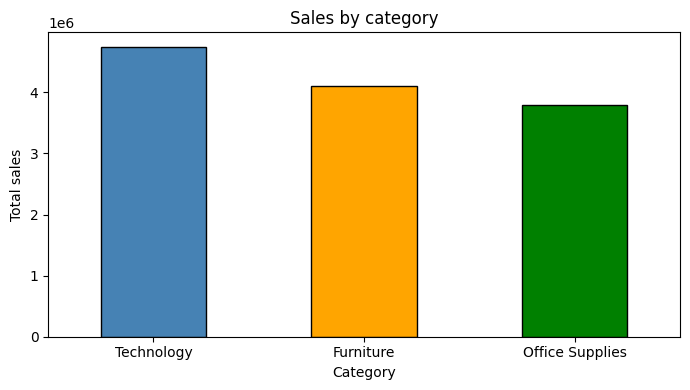

In [10]:
plt.figure(figsize=(7, 4))
sales_category.plot(kind='bar', color=['steelblue', 'orange', 'green'], edgecolor='black')
plt.title('Sales by category')
plt.xlabel('Category')
plt.ylabel('Total sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
profit_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(profit_region)

Region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           120089.11200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: Profit, dtype: float64


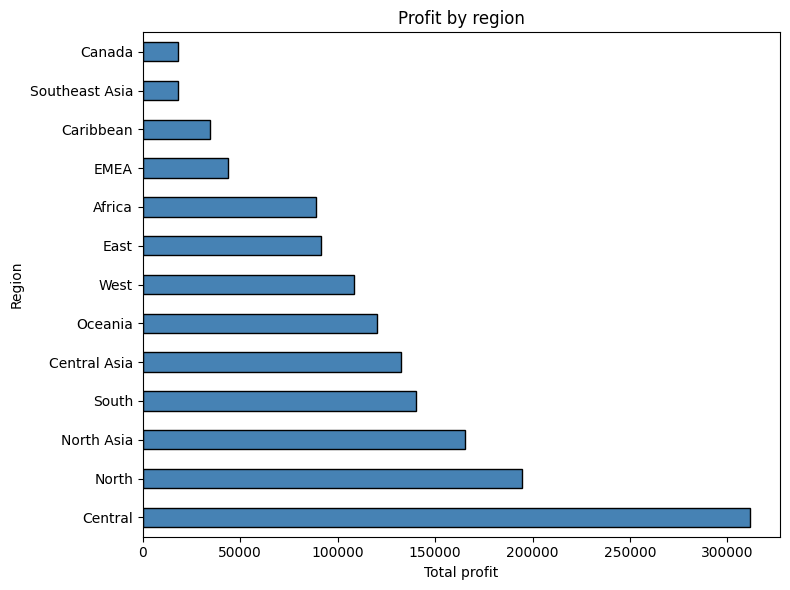

In [16]:
plt.figure(figsize=(8, 6))
profit_region.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Profit by region')
plt.xlabel('Total profit')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

In [17]:
year_sales = df.groupby('Year')['Sales'].sum()
print(year_sales)

Year
2011    2259511
2012    2677493
2013    3405860
2014    4300041
Name: Sales, dtype: int64


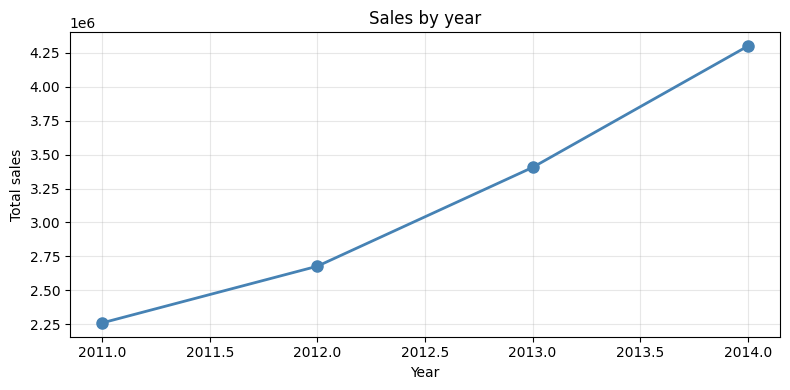

In [18]:
plt.figure(figsize=(8, 4))
year_sales.plot(kind='line', marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title('Sales by year')
plt.xlabel('Year')
plt.ylabel('Total sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
top_products = df.groupby('Product.Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

Product.Name
Apple Smart Phone, Full Size                                86936
Cisco Smart Phone, Full Size                                76441
Motorola Smart Phone, Full Size                             73159
Nokia Smart Phone, Full Size                                71904
Canon imageCLASS 2200 Advanced Copier                       61600
Hon Executive Leather Armchair, Adjustable                  58200
Office Star Executive Leather Armchair, Adjustable          50667
Harbour Creations Executive Leather Armchair, Adjustable    50120
Samsung Smart Phone, Cordless                               48654
Nokia Smart Phone, with Caller ID                           47880
Name: Sales, dtype: int64


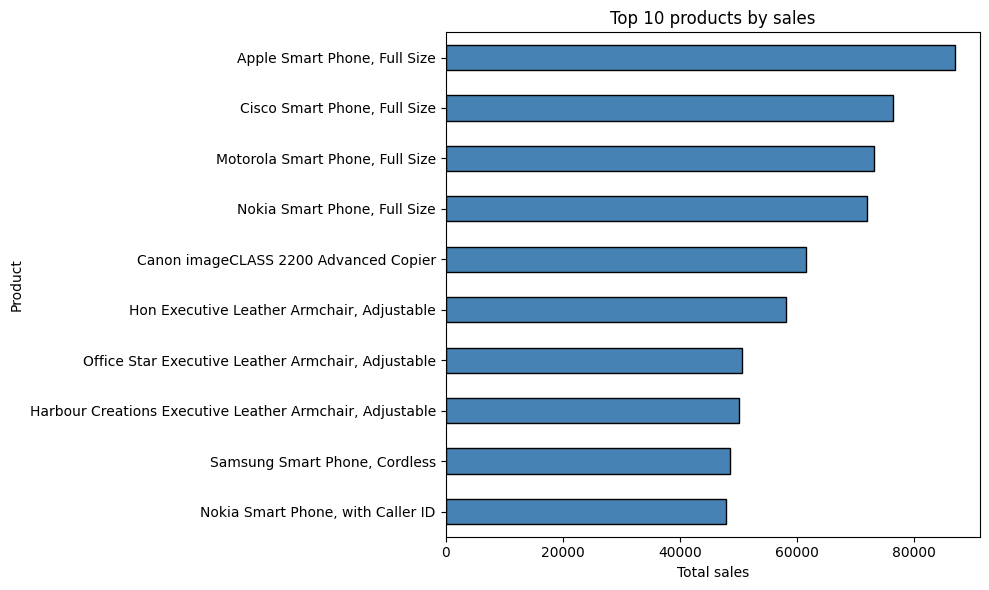

In [23]:
plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 products by sales')
plt.xlabel('Total sales')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

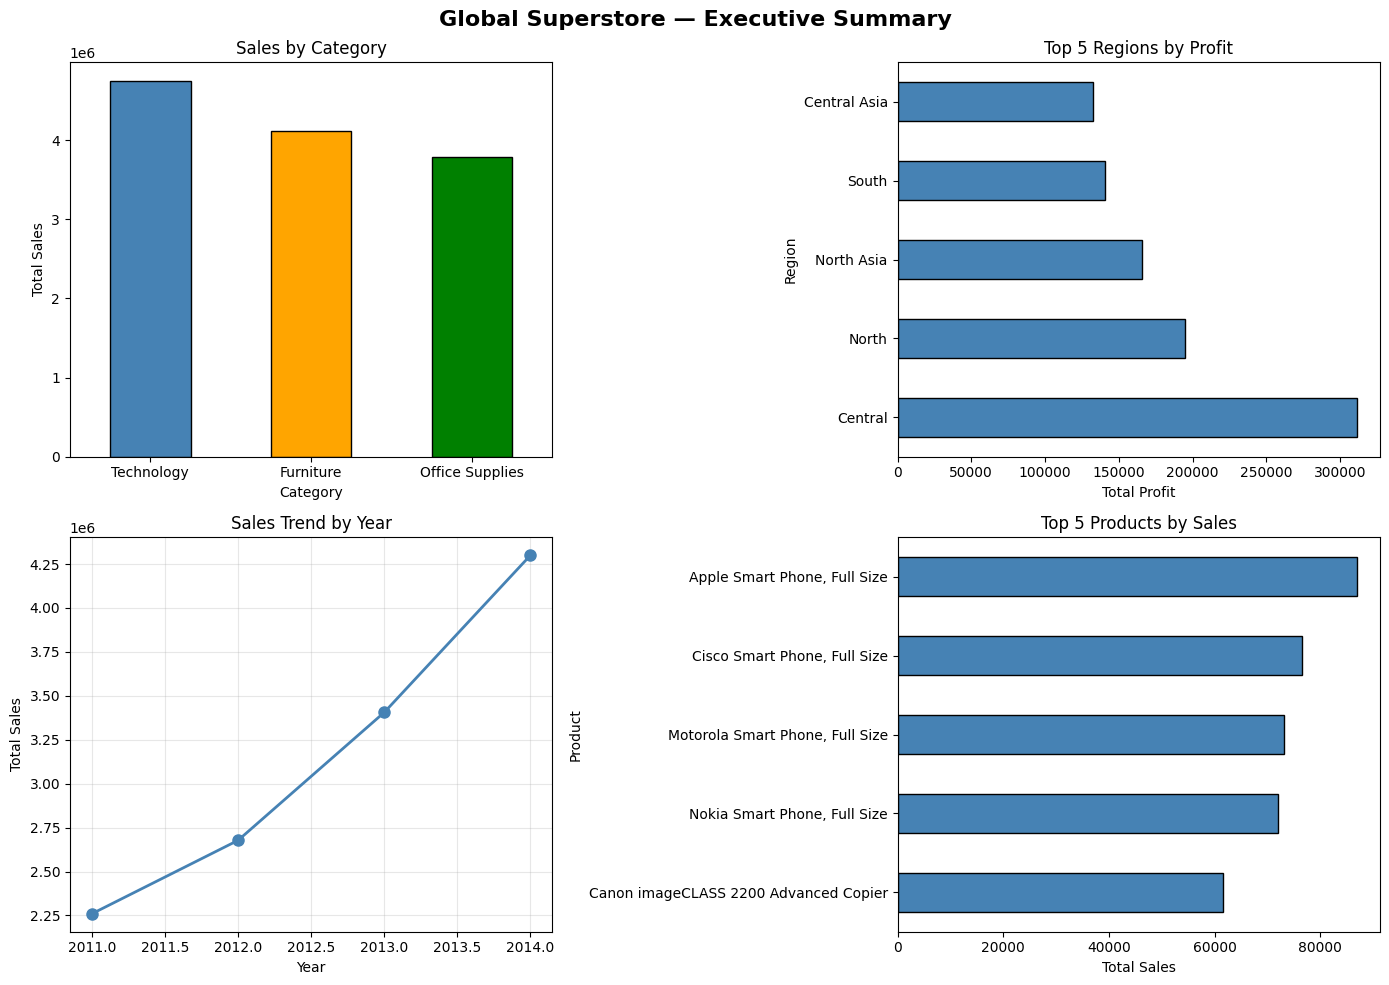

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfica 1 — Ventas por categoría
sales_category.plot(kind='bar', ax=axes[0,0], color=['steelblue','orange','green'], edgecolor='black')
axes[0,0].set_title('Sales by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Total Sales')
axes[0,0].tick_params(axis='x', rotation=0)

# Gráfica 2 — Profit por región (top 5)
profit_region.head(5).plot(kind='barh', ax=axes[0,1], color='steelblue', edgecolor='black')
axes[0,1].set_title('Top 5 Regions by Profit')
axes[0,1].set_xlabel('Total Profit')
axes[0,1].set_ylabel('Region')

# Gráfica 3 — Tendencia de ventas
year_sales.plot(kind='line', ax=axes[1,0], marker='o', color='steelblue', linewidth=2, markersize=8)
axes[1,0].set_title('Sales Trend by Year')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Total Sales')
axes[1,0].grid(True, alpha=0.3)

# Gráfica 4 — Top 5 productos
top_products.head(5).sort_values().plot(kind='barh', ax=axes[1,1], color='steelblue', edgecolor='black')
axes[1,1].set_title('Top 5 Products by Sales')
axes[1,1].set_xlabel('Total Sales')
axes[1,1].set_ylabel('Product')

plt.suptitle('Global Superstore — Executive Summary', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('Superstore_Summary.png', dpi=150, bbox_inches='tight')
plt.show()